In [1]:
# analyze_confidence_thresholds.py
import yaml
import argparse
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.ticker import FixedLocator, FixedFormatter
import plotly.graph_objects as go

def compute_wilson_ci(success_count: int, total_count: int, z: float = 1.96):
    """
    Wilson score interval for a binomial proportion.
    Returns (ci_lower, ci_upper).
    """
    if total_count == 0:
        return np.nan, np.nan

    p = success_count / total_count
    denom = 1 + (z**2) / total_count
    center = (p + (z**2) / (2 * total_count)) / denom
    margin = (
        z
        * np.sqrt((p * (1 - p) / total_count) + (z**2) / (4 * total_count**2))
        / denom
    )

    ci_lower = max(0.0, center - margin)
    ci_upper = min(1.0, center + margin)
    return ci_lower, ci_upper


def analyze_threshold_performance(
    df: pd.DataFrame, 
    score_column: str, 
    threshold: float,
    greater_is_better: bool = True
) -> dict:
    """
    分析在给定置信度分数和阈值下，筛选后数据的准确率和覆盖率。

    Args:
        df (pd.DataFrame): 包含所有数据的 Master DataFrame。
        score_column (str): 要用作筛选依据的置信度分数所在的列名
                            (e.g., 'Quantitative_Score', 'Semantic_Score').
        threshold (float): 用于筛选的置信度阈值。
        greater_is_better (bool): 分数的方向性。True表示分数越高越好，
                                  False表示分数越低越好。

    Returns:
        dict: 一个包含详细分析结果的字典。
    """
    
    # --- 1. Filter data by threshold ---
    if greater_is_better:
        filtered_df = df[df[score_column] >= threshold]
    else:
        # For metrics such as redundancy, where lower values are better
        filtered_df = df[df[score_column] <= threshold]

    # --- 2. Initialize result storage ---
    results = {
        'score_column': score_column,
        'threshold': threshold,
        'greater_is_better': greater_is_better,
        'by_dataset': {},
        'overall': {}
    }

    # --- 3. Calculate performance for each individual dataset ---
    # Get all dataset names present in the data
    datasets_in_df = df['dataset'].unique()
    
    for dataset in datasets_in_df:
        # Get this dataset from both the original and filtered DataFrames
        original_subset = df[df['dataset'] == dataset]
        filtered_subset = filtered_df[filtered_df['dataset'] == dataset]

        # Calculate the number and proportion of retained records (coverage)
        retained_count = len(filtered_subset)
        total_count = len(original_subset)
        coverage = retained_count / total_count if total_count > 0 else 0
        coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)
        
        # Calculate accuracy after filtering.
        if retained_count > 0:
            accuracy = filtered_subset['final_decision'].mean()
            correct_retained_count = int(filtered_subset['final_decision'].sum())
            accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
        else:
            accuracy = np.nan
            correct_retained_count = 0
            accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan


        results['by_dataset'][dataset] = {
            'accuracy': accuracy,
            'accuracy_ci_lower': accuracy_ci_lower,
            'accuracy_ci_upper': accuracy_ci_upper,
            'correct_retained_count': correct_retained_count,
            'retained_count': retained_count,
            'total_count': total_count,
            'coverage': coverage,
            'coverage_ci_lower': coverage_ci_lower,
            'coverage_ci_upper': coverage_ci_upper,
        }

        
    # --- 4. Calculate overall performance ---
    overall_total_count = len(df)
    overall_retained_count = len(filtered_df)
    overall_coverage = overall_retained_count / overall_total_count if overall_total_count > 0 else 0
    overall_coverage_ci_lower, overall_coverage_ci_upper = compute_wilson_ci(
        overall_retained_count,
        overall_total_count
    )
    
    if overall_retained_count > 0:
        overall_accuracy = filtered_df['final_decision'].mean()
        overall_correct_retained_count = int(filtered_df['final_decision'].sum())
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = compute_wilson_ci(
            overall_correct_retained_count,
            overall_retained_count
        )
    else:
        overall_accuracy = np.nan
        overall_correct_retained_count = 0
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = np.nan, np.nan


    results['overall'] = {
        'accuracy': overall_accuracy,
        'accuracy_ci_lower': overall_accuracy_ci_lower,
        'accuracy_ci_upper': overall_accuracy_ci_upper,
        'correct_retained_count': overall_correct_retained_count,
        'retained_count': overall_retained_count,
        'total_count': overall_total_count,
        'coverage': overall_coverage,
        'coverage_ci_lower': overall_coverage_ci_lower,
        'coverage_ci_upper': overall_coverage_ci_upper,
    }
    
    return results


def print_results(results: dict):
    """一个辅助函数，用于美观地打印分析结果。"""
    print("\n" + "="*60)
    print(f"Confidence Threshold Analysis Report")
    print(f"  - Score Column: '{results['score_column']}'")
    print(f"  - Threshold: >= {results['threshold']}" if results['greater_is_better'] else f"  - Threshold: <= {results['threshold']}")
    print("="*60)
    
    print("\n--- Performance by Dataset ---")
    for dataset, data in results['by_dataset'].items():
        print(f"  - {dataset}:")
        if data['retained_count'] > 0:
            print(
                f"    - Accuracy: {data['accuracy']:.2%} "
                f"[95% CI {data['accuracy_ci_lower']:.2%}–{data['accuracy_ci_upper']:.2%}]"
            )
        else:
            print(f"    - Accuracy: N/A")
        # print(f"    - Coverage: {data['coverage']:.2%} ({data['retained_count']} / {data['total_count']} records retained)")
        print(
            f"    - Coverage: {data['coverage']:.2%} "
            f"[95% CI {data['coverage_ci_lower']:.2%}–{data['coverage_ci_upper']:.2%}] "
            f"({data['retained_count']} / {data['total_count']} records retained)"
        )

    print("\n--- Overall Performance ---")
    overall_data = results['overall']
    if overall_data['retained_count'] > 0:
        print(
            f"    - Accuracy: {overall_data['accuracy']:.2%} "
            f"[95% CI {overall_data['accuracy_ci_lower']:.2%}–{data['accuracy_ci_upper']:.2%}]"
        )
    else:
        print(f"  - Accuracy: N/A")
    # print(f"  - Coverage: {overall_data['coverage']:.2%} ({overall_data['retained_count']} / {overall_data['total_count']} records retained)")
    print(
        f"  - Coverage: {overall_data['coverage']:.2%} "
        f"[95% CI {overall_data['coverage_ci_lower']:.2%}–{overall_data['coverage_ci_upper']:.2%}] "
        f"({overall_data['retained_count']} / {overall_data['total_count']} records retained)"
    )
    print("="*60)


def calculate_performance_curves(df: pd.DataFrame, score_column: str, greater_is_better: bool = True, threshold_range: np.ndarray = None) -> pd.DataFrame:
    """
    为给定的分数，在一系列阈值上计算准确率和覆盖率，以生成曲线数据。
    """
    # Automatically generate thresholds when none are provided
    if threshold_range is None:
        min_score, max_score = df[score_column].min(), df[score_column].max()
        threshold_range = np.linspace(min_score, max_score, 50) # Generate 50 test points.
        
    all_curves_data = []
        
    datasets_to_plot = list(df['dataset'].unique()) + ["Overall"]

    for dataset_name in datasets_to_plot:
        if dataset_name == "Overall":
            df_subset = df
        else:
            df_subset = df[df['dataset'] == dataset_name]
        
        total_count = len(df_subset)
        
        for t in threshold_range:
            if greater_is_better:
                filtered_df = df_subset[df_subset[score_column] >= t]
            else:
                filtered_df = df_subset[df_subset[score_column] <= t]
            
            retained_count = len(filtered_df)
            coverage = retained_count / total_count if total_count > 0 else 0
            coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)
            if retained_count > 0:
                accuracy = filtered_df['final_decision'].mean()
                correct_retained_count = int(filtered_df['final_decision'].sum())
                accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
            else:
                accuracy = np.nan
                correct_retained_count = 0
                accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan

            
            all_curves_data.append({
                'dataset': dataset_name,
                'threshold': t,
                'accuracy': accuracy,
                'accuracy_ci_lower': accuracy_ci_lower,
                'accuracy_ci_upper': accuracy_ci_upper,
                'correct_retained_count': correct_retained_count,
                'coverage': coverage,
                'retained_count': retained_count,
                'total_count': total_count,
                'coverage_ci_lower': coverage_ci_lower,
                'coverage_ci_upper': coverage_ci_upper,
            })
            
    return pd.DataFrame(all_curves_data)

In [ ]:

# --- 1. Global style configuration ---
def setup_style():
    try:
        arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
        fm.fontManager.addfont(arial_path)
        plt.rcParams['font.family'] = 'Arial'
    except FileNotFoundError:
        print("警告: Arial 字体未找到，将使用默认无衬线字体。")
        plt.rcParams['font.family'] = 'sans-serif'

    plt.rcParams['font.size'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['xtick.labelsize'] = 5
    plt.rcParams['ytick.labelsize'] = 5
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['lines.linewidth'] = 1.0
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42
    plt.rcParams['svg.fonttype'] = 'none'


setup_style()

def _mm_to_inches(mm: float) -> float:
    return mm / 25.4

def _save_dual(fig, output_dir: str, stem: str):
    os.makedirs(output_dir, exist_ok=True)
    svg_path = os.path.join(output_dir, f"{stem}.svg")
    pdf_path = os.path.join(output_dir, f"{stem}.pdf")
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    print(f"  - Saved: {svg_path}")
    print(f"  - Saved: {pdf_path}")


def plot_tradeoff_bar(
    df_curves: pd.DataFrame,
    score_column: str,
    output_dir: str,
    bar_color: str = "#3B91C2",
):
    df_overall = df_curves[df_curves['dataset'] == 'Overall'].dropna()
    if df_overall.empty:
        print("  - WARNING: No data to plot for Overall curve.")
        return

    thresholds = df_overall['threshold'].to_numpy(dtype=float)
    acc_vals   = (df_overall['accuracy'].to_numpy(dtype=float) * 100.0)
    cov_vals   = (df_overall['coverage'].to_numpy(dtype=float) * 100.0)

    # —— Expand the left axis to 90-100 —— #
    BASE = 80.0
    acc_plot = np.clip(acc_vals - BASE, 0, None)  # y = 0 corresponds to 90%.

    # Bar width (supports uneven threshold spacing)
    if len(thresholds) > 1:
        diffs = np.diff(np.sort(thresholds))
        step = np.min(diffs[diffs > 0]) if np.any(diffs > 0) else (thresholds.max() - thresholds.min())/max(len(thresholds)-1,1)
        bar_width = 0.8 * step
    else:
        bar_width = 0.1

    # fig, ax = plt.subplots(figsize=(5, 4), dpi=600)
    single_col_w = _mm_to_inches(60)
    fig, ax = plt.subplots(figsize=(single_col_w, 2.0), dpi=600)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(0.4)
    ax.spines['bottom'].set_linewidth(0.4)
    # ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')

    # Visible height of the upper enlarged region: at least 15 (fine-tune to 12-18)
    top_span = max(10.1, float(np.nanmax(acc_plot) if acc_plot.size else 0.0) + 2.0)

    # —— Key: compress the coverage plotting scale —— #
    # Map Coverage 0-100 to 0 -> -top_span in the lower region
    NEG_SCALE = top_span / 100.0
    cov_plot = -cov_vals * NEG_SCALE  # Plot on the same axis: larger values are lower, with a compressed scale.

    # Bars.
    bars_acc = ax.bar(thresholds, acc_plot, width=bar_width, color=bar_color, alpha=1.0, label='Accuracy')
    bars_cov = ax.bar(thresholds, cov_plot, width=bar_width, color=bar_color, 
                      hatch='///', edgecolor='white', linewidth=0.6, label='Coverage')
    # y = 0 dividing line.
    # ax.axhline(0, color='black', linewidth=0.3, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.25, linestyle=(0, (8, 6)))

    # Use symmetric visible ranges above and below
    ax.set_ylim(-top_span, top_span)

    # Left axis: display 0,5,10,15... as 85,90,95,100...
    left_ticks_pos = np.arange(0, 20+0.1, 5)  # 0,5,10,15
    left_ticks_lab = [f"{BASE + t:.0f}" for t in left_ticks_pos]
    ax.yaxis.set_major_locator(FixedLocator(left_ticks_pos))
    ax.yaxis.set_major_formatter(FixedFormatter(left_ticks_lab))
    ax.set_ylabel("Accuracy (%)")

    # Right axis: map Coverage 0-100 tick positions to the negative lower region (multiply by NEG_SCALE)
    axR = ax.twinx()
    axR.spines['top'].set_visible(False)
    axR.spines['left'].set_visible(False)
    axR.spines['right'].set_linewidth(0.4)
    axR.spines['right'].set_color('#888888')

    right_ticks_val = np.arange(0, 101, 20)                # 0, 20, ..., 100 (actual values).
    right_ticks_pos = -(right_ticks_val * NEG_SCALE)       # Positions mapped to the negative lower region.
    axR.yaxis.set_major_locator(FixedLocator(right_ticks_pos))
    axR.yaxis.set_major_formatter(FixedFormatter([f"{v:.0f}" for v in right_ticks_val]))
    axR.set_ylim(ax.get_ylim())                            # Match the visible range of the left axis.
    axR.set_ylabel("Coverage (%)", color="#606060") #"#808080"
    # axR.tick_params(axis='y', colors="#808080", direction='out')
    axR.tick_params(axis='y', colors="#606060", direction='out', width=0.5, length=2) #"#808080"


    # X-axis.
    ax.set_xlabel(f"{score_column} threshold")
    # ax.tick_params(axis='x', which='major', direction='out')
    ax.tick_params(axis='x', which='major', direction='out', width=0.5, length=2)
    ax.tick_params(axis='y', which='major', direction='out', width=0.5, length=2)

    # Value labels: display actual percentages for both Accuracy and Coverage
    for b, val in zip(bars_acc, acc_vals):
        h = b.get_height()
        if val > 0:
            ax.annotate(f"{val:.1f}", xy=(b.get_x()+b.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=6)
    for b, val in zip(bars_cov, cov_vals):
        if val > 0:
            ax.annotate(f"{val:.1f}", xy=(b.get_x()+b.get_width()/2, -(val*NEG_SCALE)),
                        xytext=(0, -3), textcoords="offset points",
                        ha='center', va='top', fontsize=6, color="#606060")

    ax.legend(loc='upper left', bbox_to_anchor=(0.0, 1.08), frameon=False, fontsize=5)

    # out = os.path.join(output_dir, f"tradeoff_barbar_dualaxis_overall_{score_column}_zoom85.svg")
    plt.tight_layout()
    _save_dual(fig, output_dir, f"tradeoff_barbar_dualaxis_overall_{score_column}_zoom85")
    # plt.close(fig)



def plot_triage_sankey(df, output_dir, score_column='Consistency_Dx', threshold=0.8):
    """
    绘制临床分流桑基图。
    展示：Total Cases -> (Filter) -> Auto/Human -> Outcome
    """
    print(f"  - Generating Triage Sankey Diagram (Threshold={threshold})...")
    
    # 1. Prepare data
    # Assume Consistency_Dx is used as the filter
    df = df.copy()
    df['is_high_conf'] = df[score_column] >= threshold
    df['is_correct'] = df['final_decision']
    
    # Calculate counts for each flow
    total = len(df)
    
    # High Confidence (Auto)
    auto_total = df[df['is_high_conf']].shape[0]
    auto_correct = df[df['is_high_conf'] & df['is_correct']].shape[0]
    auto_error = auto_total - auto_correct
    
    # Low Confidence (Human)
    human_total = df[~df['is_high_conf']].shape[0]
    human_correct_potential = df[~df['is_high_conf'] & df['is_correct']].shape[0] # Cases the AI would have answered correctly but that were intercepted.
    human_error_potential = df[~df['is_high_conf'] & ~df['is_correct']].shape[0] # Cases the AI would have answered incorrectly and that were successfully intercepted.
    
    # 2. Define nodes (Nodes)
    labels = [
        f"Total Cases<br>(n={total})",       # 0
        f"AI Autonomy<br>(n={auto_total})",  # 1
        f"Human Review<br>(n={human_total})", # 2
        f"Autonomous Correct<br>(n={auto_correct})",   # 3
        f"Autonomous Error<br>(n={auto_error})",     # 4
        f"Deferred Correct<br>(n={human_correct_potential})", # 5
        f"Deferred Error<br>(n={human_error_potential})"   # 6
    ]

    color_node = [
        "#707070",  # Total: neutral gray.
        "#3B91C2",  # Auto: primaryblue
        "#E58B73",  # Human: soft orange-red.
        "#2c77a0",  # Success: blue
        "#B43C3C",  # Missed error: darkred
        "#9CC9E5",  # Review non-errors: lightblue
        "#F3B49A",  # Review errors: lightorange
    ]

    # 3. Define links (Links)
    # Source -> Target, Value
    source = [0, 0, 1, 1, 2, 2]
    target = [1, 2, 3, 4, 5, 6]
    value =  [
        auto_total, human_total,      # Total flow split.
        auto_correct, auto_error,     # Auto results
        human_correct_potential, human_error_potential # Human results
    ]

    color_link = [
        "rgba(59, 145, 194, 0.35)",  # Total -> Auto
        "rgba(229, 139, 115, 0.35)", # Total -> Human
        "rgba(59, 145, 194, 0.75)",  # Auto -> Correct
        "rgba(180, 60, 60, 0.85)",   # Auto -> Error
        "rgba(156, 201, 229, 0.45)", # Human -> Potential correct
        "rgba(243, 180, 154, 0.70)", # Human -> Intercepted error
    ]

    # 4. Plot
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=8,
            thickness=10,
            line=dict(color="rgba(80,80,80,0.18)", width=0.4),
            label=labels,
            color=color_node,
            # x/y are normalized coordinates in [0, 1]
            # y=0 is top, y=1 is bottom
            # x=[0.02, 0.38, 0.38, 0.76, 0.76, 0.76, 0.76],
            x=[0.01, 0.4, 0.4, 0.94, 0.94, 0.94, 0.94],

            y=[0.5, 0.25, 0.71, 0.20, 0.96, 0.61, 0.86]
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=color_link
        )
    )])

    half_double_col_px = int((180 / 4) / 25.4 * 96)

    fig.update_layout(
        title=dict(
            text=f"Clinical Triage Workflow ({score_column} threshold = {threshold:.2f})",
            x=0.0,
            xanchor="left",
            y=0.98,
            font=dict(size=7, family="Arial"),# color="#000000"),
        ),
        font=dict(size=6, family="Arial"), #color="#000000"),
        # width=half_double_col_px,
        # height=int((180 / 4) / 25.4 * 96),          # Slightly flatter.
        width=400,           # Approximately double-column width (7.2 in * 100).
        height=250,  
        # margin=dict(l=10, r=10, t=35, b=10),
        margin=dict(l=2, r=2, t=20, b=2),
        paper_bgcolor="white",
        plot_bgcolor="white",
    )
    fig.update_layout(font_shadow="")
    fig.show()
    
    # Save
    os.makedirs(output_dir, exist_ok=True)
    fig.write_image(os.path.join(output_dir, f"Triage_Sankey_{threshold}.svg"))
    fig.write_image(os.path.join(output_dir, f"Triage_Sankey_{threshold}.pdf"))
    fig.write_html(os.path.join(output_dir, f"Triage_Sankey_{threshold}.html"))


✅ Successfully loaded Master DataFrame with 551 records.

--- Running Single-Point Threshold Analysis ---

Confidence Threshold Analysis Report
  - Score Column: 'Consistency_Dx'
  - Threshold: >= 0.85

--- Performance by Dataset ---
  - appendicitis:
    - Accuracy: 100.00% [95% CI 97.23%–100.00%]
    - Coverage: 91.22% [95% CI 85.55%–94.79%] (135 / 148 records retained)
  - cholecystitis:
    - Accuracy: 93.18% [95% CI 85.91%–96.84%]
    - Coverage: 68.22% [95% CI 59.75%–75.63%] (88 / 129 records retained)
  - diverticulitis:
    - Accuracy: 97.06% [95% CI 85.08%–99.48%]
    - Coverage: 62.96% [95% CI 49.63%–74.58%] (34 / 54 records retained)
  - pancreatitis:
    - Accuracy: 100.00% [95% CI 87.94%–100.00%]
    - Coverage: 53.85% [95% CI 40.50%–66.66%] (28 / 52 records retained)
  - pneumonia:
    - Accuracy: 75.00% [95% CI 30.06%–95.44%]
    - Coverage: 13.79% [95% CI 5.50%–30.56%] (4 / 29 records retained)
  - pulmonary_embolism:
    - Accuracy: 98.08% [95% CI 89.88%–99.66%]
    - 


--- Running Single-Point Threshold Analysis ---

Confidence Threshold Analysis Report
  - Score Column: 'ProbScore_Dx'
  - Threshold: >= 0.85

--- Performance by Dataset ---
  - appendicitis:
    - Accuracy: 97.96% [95% CI 94.17%–99.30%]
    - Coverage: 99.32% [95% CI 96.27%–99.88%] (147 / 148 records retained)
  - cholecystitis:
    - Accuracy: 90.62% [95% CI 84.33%–94.56%]
    - Coverage: 99.22% [95% CI 95.74%–99.86%] (128 / 129 records retained)
  - diverticulitis:
    - Accuracy: 94.44% [95% CI 84.89%–98.09%]
    - Coverage: 100.00% [95% CI 93.36%–100.00%] (54 / 54 records retained)
  - pancreatitis:
    - Accuracy: 92.31% [95% CI 81.83%–96.97%]
    - Coverage: 100.00% [95% CI 93.12%–100.00%] (52 / 52 records retained)
  - pneumonia:
    - Accuracy: 55.56% [95% CI 37.31%–72.41%]
    - Coverage: 93.10% [95% CI 78.04%–98.09%] (27 / 29 records retained)
  - pulmonary_embolism:
    - Accuracy: 89.89% [95% CI 81.89%–94.59%]
    - Coverage: 98.89% [95% CI 93.97%–99.80%] (89 / 90 records

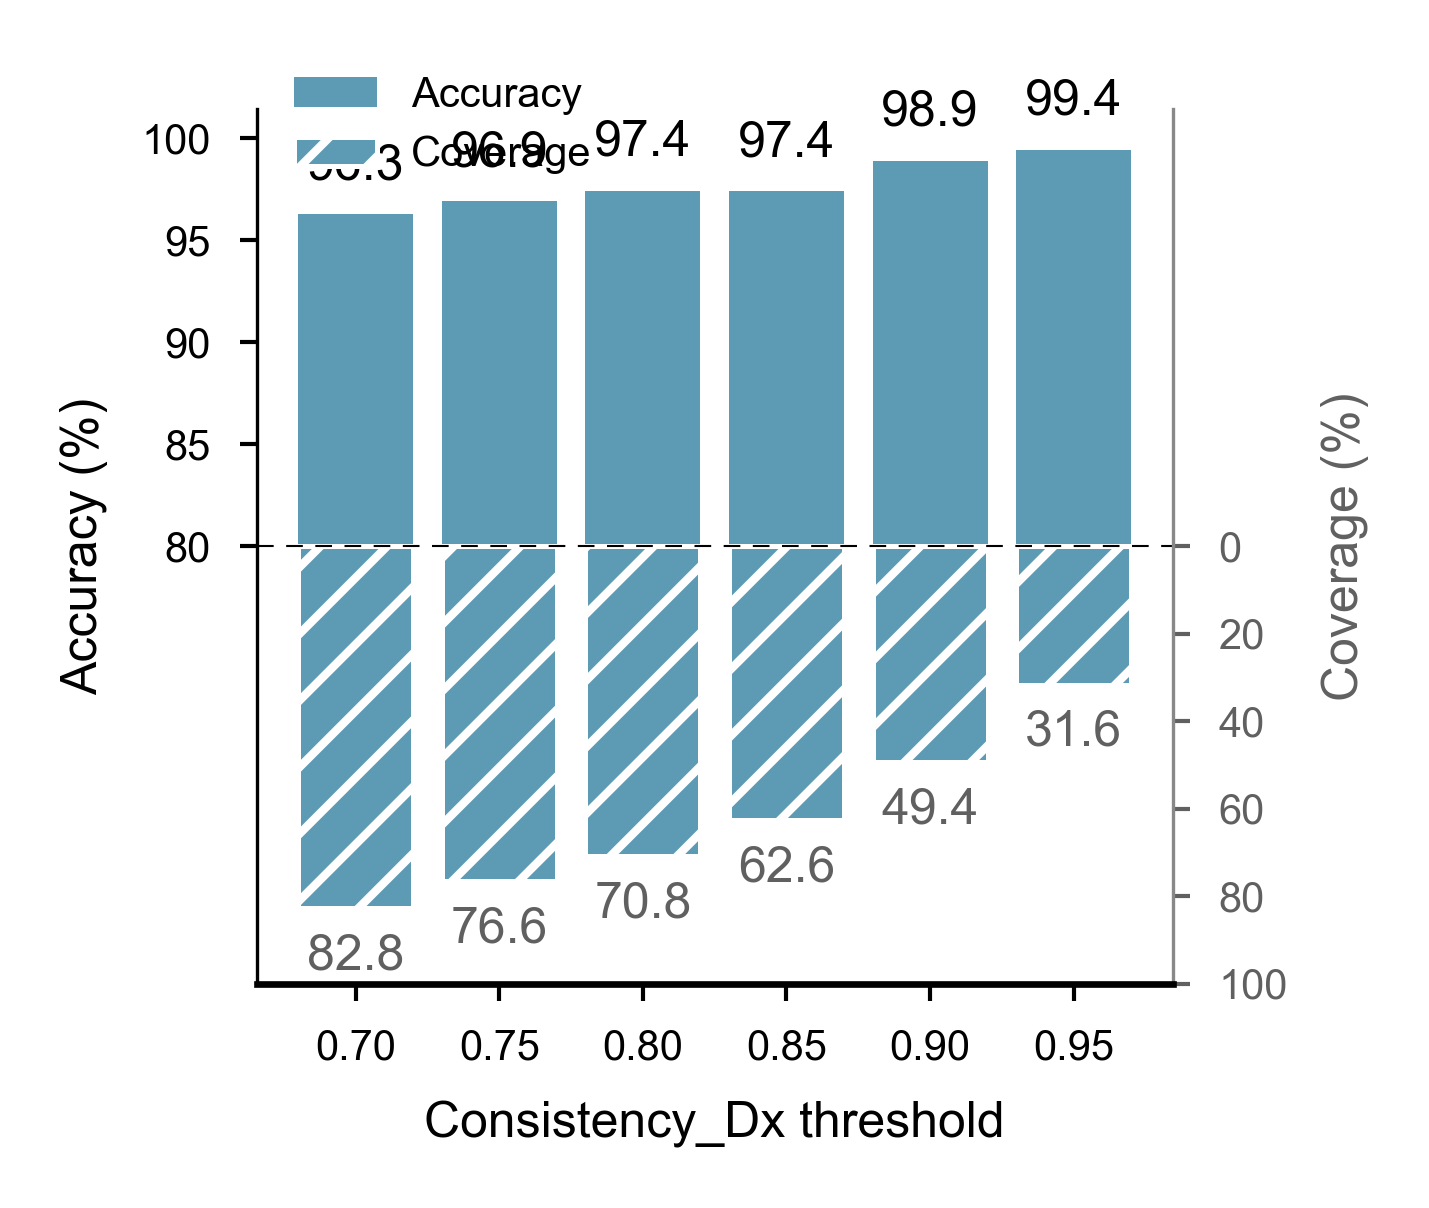

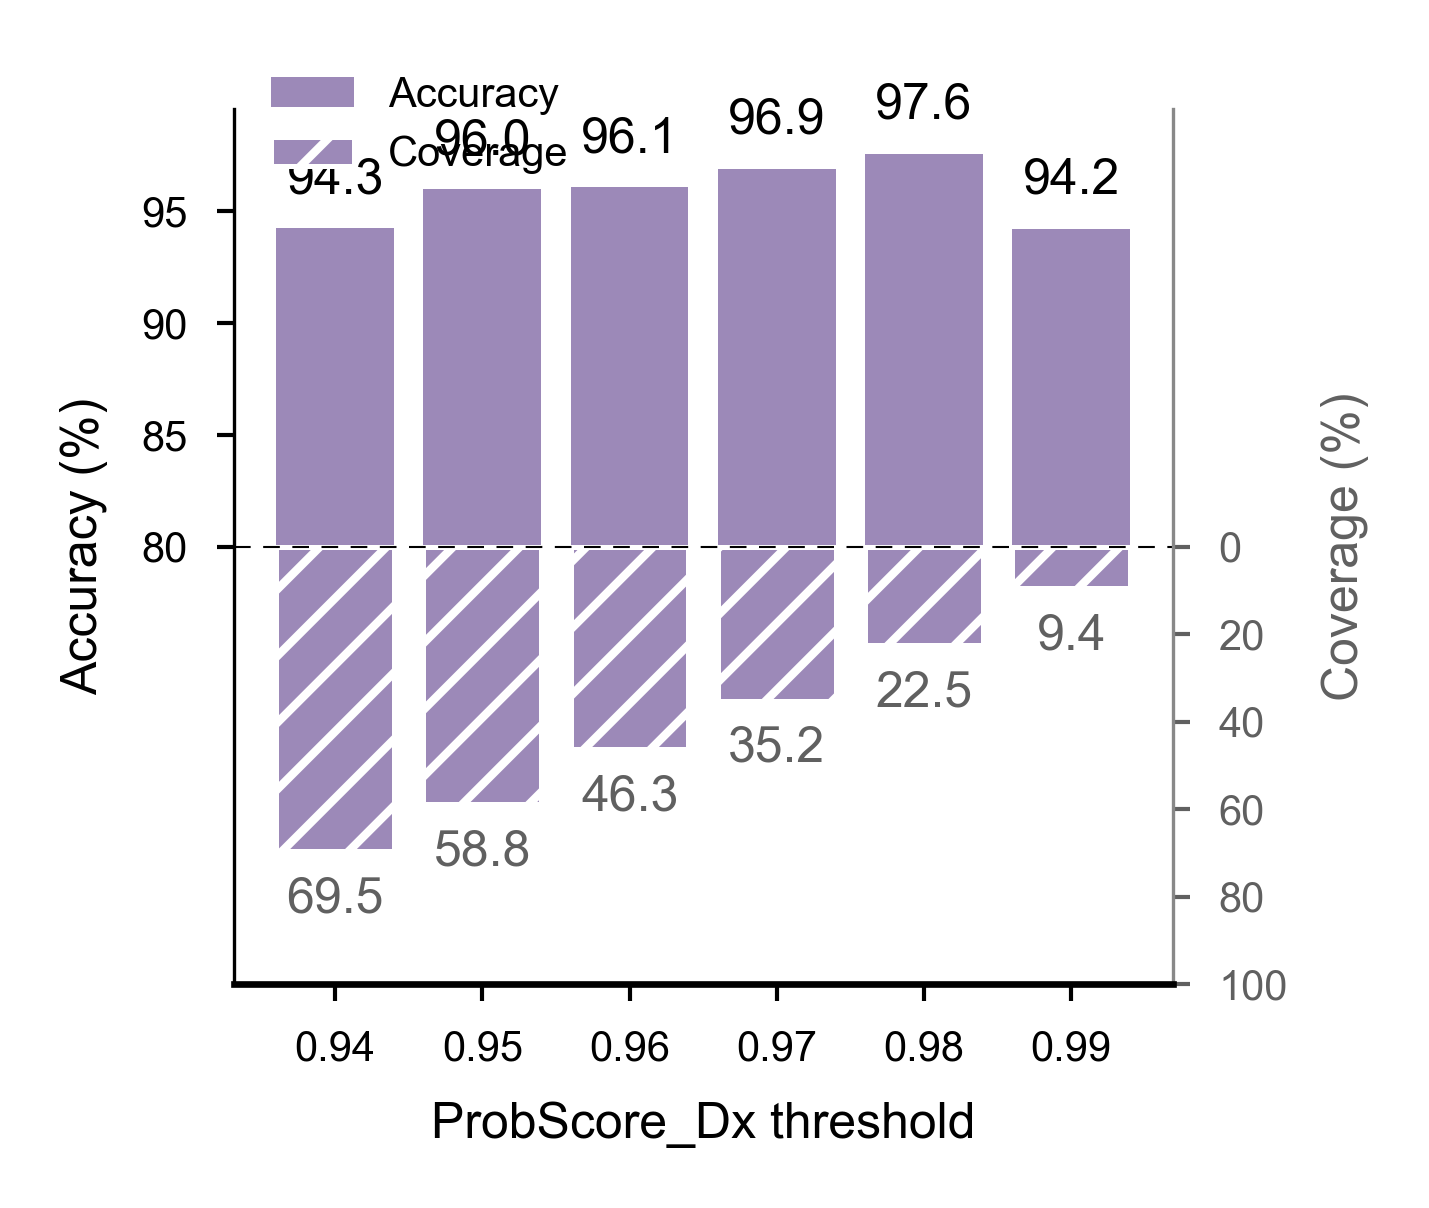

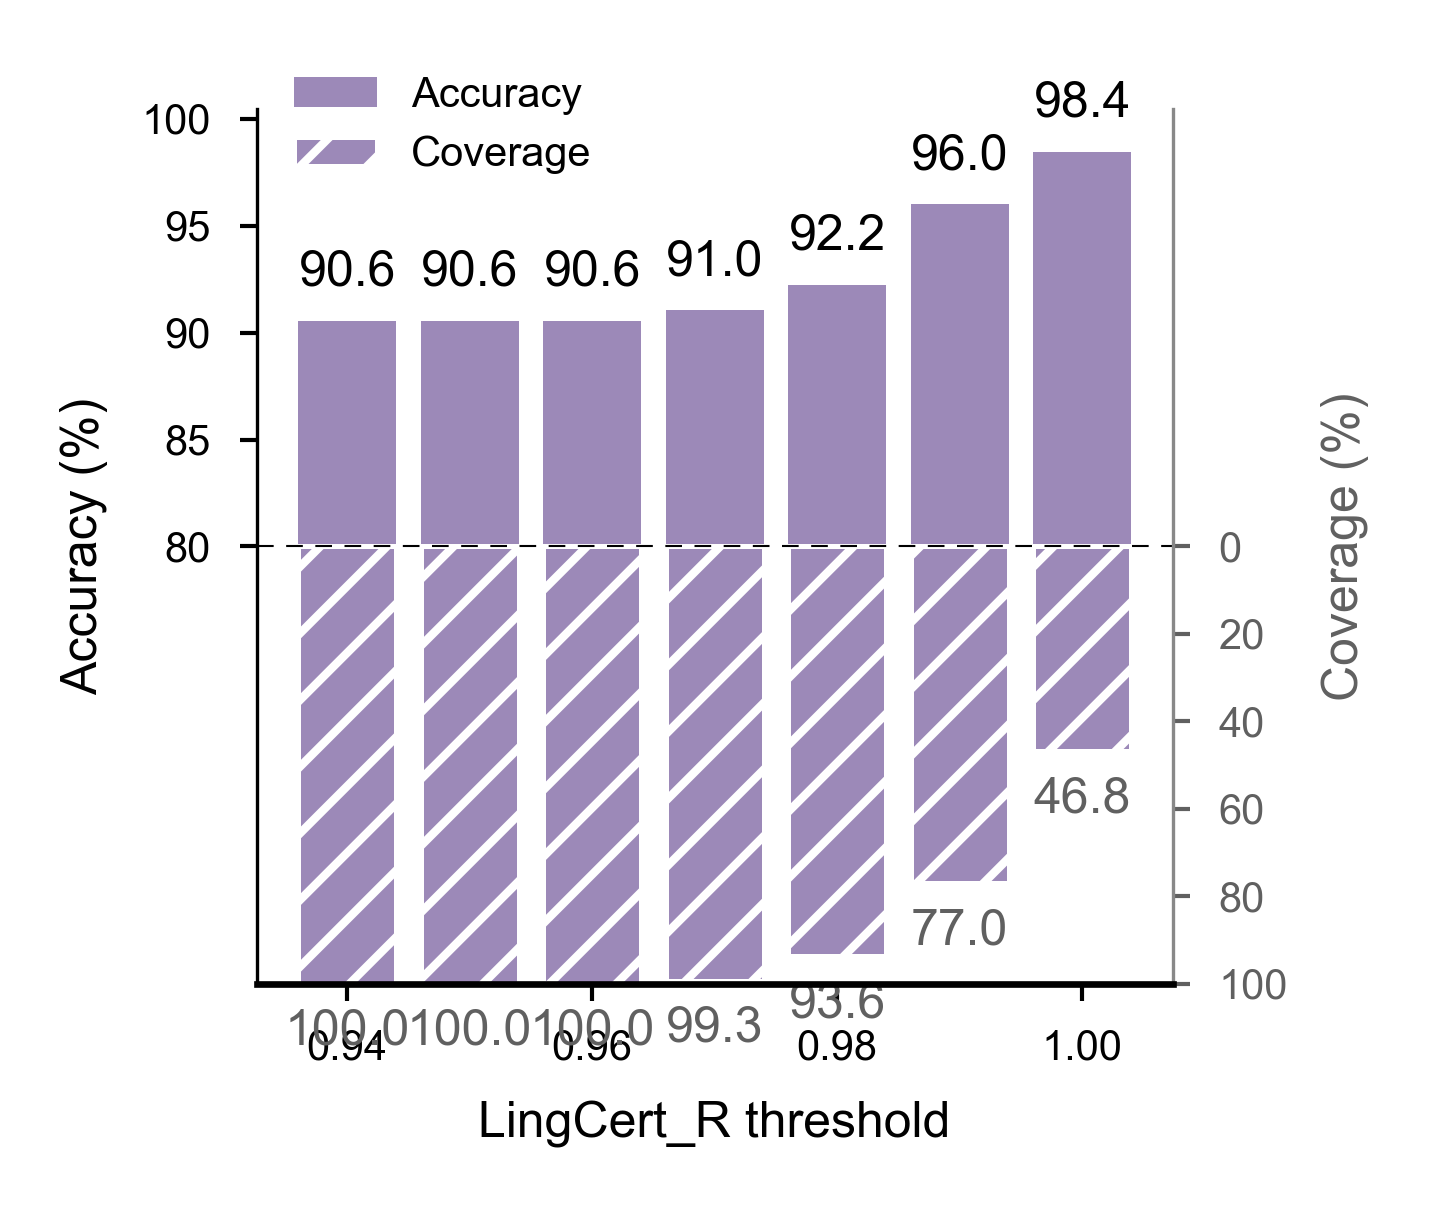

In [ ]:
# --- 1. Load the main data file ---

try:
    df_master =pd.read_csv('/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/master_feature_dataframe.csv')
    
    print(f"✅ Successfully loaded Master DataFrame with {len(df_master)} records.")
except FileNotFoundError:
    print("❌ ERROR: Master DataFrame not found.")
    exit()

# --- 2. Run single-point analysis (optional; retain or comment out) ---
print("\n--- Running Single-Point Threshold Analysis ---")
conf_results = analyze_threshold_performance(
    df=df_master,
    score_column='Consistency_Dx',
    threshold=0.85,
    greater_is_better=True
)
print_results(conf_results)

# --- 3. Run curve analysis ---
print("\n--- Running Threshold Curve Analysis ---")

save_dir = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_5runs/threshold_basic'
os.makedirs(save_dir, exist_ok=True)

# a. Analyze Consistency_Dx
score_to_analyze = 'Consistency_Dx'
print(f"  - Generating curves for '{score_to_analyze}'...")

custom_thresholds = np.arange(0.7, 1.01, 0.05)
# This generates [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

print(f"    - Using custom thresholds: {np.round(custom_thresholds, 2)}")

curves_df = calculate_performance_curves(df_master, score_to_analyze, greater_is_better=True, threshold_range=custom_thresholds)
csv_path = os.path.join(save_dir, f'threshold_curves_{score_to_analyze}.csv')
curves_df.to_csv(csv_path, index=False)
print(f"Saved curve data to: {csv_path}")

plot_tradeoff_bar(curves_df, score_to_analyze, save_dir, bar_color='#5D9BB5')
# plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.7)
# plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.75)
# plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.8)
# plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.85)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.9)
# plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.95)



# # b. (Optional) Analyze other scores.
print("\n--- Running Single-Point Threshold Analysis ---")
conf_results = analyze_threshold_performance(
    df=df_master,
    score_column='ProbScore_Dx',
    threshold=0.85,
    greater_is_better=True
)
print_results(conf_results)

# --- 3. Run curve analysis ---
print("\n--- Running Threshold Curve Analysis ---")

# a. Analyze ProbScore_Dx
score_to_analyze = 'ProbScore_Dx'
print(f"  - Generating curves for '{score_to_analyze}'...")

custom_thresholds = np.arange(0.94, 1.01, 0.01)
# This generates [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

print(f"    - Using custom thresholds: {np.round(custom_thresholds, 2)}")

curves_df = calculate_performance_curves(df_master, score_to_analyze, greater_is_better=True, threshold_range=custom_thresholds)
csv_path = os.path.join(save_dir, f'threshold_curves_{score_to_analyze}.csv')
curves_df.to_csv(csv_path, index=False)
print(f"Saved curve data to: {csv_path}")

plot_tradeoff_bar(curves_df, score_to_analyze, save_dir, bar_color='#9C89B8')


# # c. (Optional) Analyze other scores - LingCert_R.
print("\n--- Running Single-Point Threshold Analysis ---")
conf_results = analyze_threshold_performance(
    df=df_master,
    score_column='LingCert_R',
    threshold=0.85,
    greater_is_better=True
)
print_results(conf_results)

# --- 3. Run curve analysis ---
print("\n--- Running Threshold Curve Analysis ---")

# a. Analyze LingCert_R
score_to_analyze = 'LingCert_R'
print(f"  - Generating curves for '{score_to_analyze}'...")

custom_thresholds = np.arange(0.94, 1.01, 0.01)
# This generates [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

print(f"    - Using custom thresholds: {np.round(custom_thresholds, 2)}")

curves_df = calculate_performance_curves(df_master, score_to_analyze, greater_is_better=True, threshold_range=custom_thresholds)
csv_path = os.path.join(save_dir, f'threshold_curves_{score_to_analyze}.csv')
curves_df.to_csv(csv_path, index=False)
print(f"Saved curve data to: {csv_path}")

plot_tradeoff_bar(curves_df, score_to_analyze, save_dir, bar_color='#9C89B8')


In [9]:
# simple version, without plot

import pandas as pd
import numpy as np


def analyze_threshold_performance_for_table(
    df: pd.DataFrame, 
    score_column: str, 
    threshold: float,
    greater_is_better: bool = True
) -> dict:
    """
    分析在给定置信度分数和阈值下，筛选后数据的准确率和覆盖率。

    Args:
        df (pd.DataFrame): 包含所有数据的 Master DataFrame。
        score_column (str): 要用作筛选依据的置信度分数所在的列名
                            (e.g., 'Quantitative_Score', 'Semantic_Score').
        threshold (float): 用于筛选的置信度阈值。
        greater_is_better (bool): 分数的方向性。True表示分数越高越好，
                                  False表示分数越低越好。

    Returns:
        dict: 一个包含详细分析结果的字典。
    """
    
    # --- 1. Filter data by threshold ---
    if greater_is_better:
        filtered_df = df[df[score_column] >= threshold]
    else:
        # For metrics such as redundancy, where lower values are better
        filtered_df = df[df[score_column] <= threshold]

    # --- 2. Initialize result storage ---
    results = {
        'score_column': score_column,
        'threshold': threshold,
        'greater_is_better': greater_is_better,
        'by_dataset': {},
        'overall': {}
    }

    # --- 3. Calculate performance for each individual dataset ---
    # Get all dataset names present in the data
    datasets_in_df = df['dataset'].unique()
    
    for dataset in datasets_in_df:
        # Get this dataset from both the original and filtered DataFrames
        original_subset = df[df['dataset'] == dataset]
        filtered_subset = filtered_df[filtered_df['dataset'] == dataset]

        # Calculate the number and proportion of retained records (coverage)
        retained_count = len(filtered_subset)
        total_count = len(original_subset)
        coverage = retained_count / total_count if total_count > 0 else 0
        
        # Calculate accuracy after filtering.
        if retained_count > 0:
            accuracy = filtered_subset['final_decision'].mean()
            correct_retained_count = int(filtered_subset['final_decision'].sum())
            accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
        else:
            accuracy = np.nan
            correct_retained_count = 0
            accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan

        coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)

        results['by_dataset'][dataset] = {
            'accuracy': accuracy,
            'accuracy_ci_lower': accuracy_ci_lower,
            'accuracy_ci_upper': accuracy_ci_upper,
            'retained_count': retained_count,
            'total_count': total_count,
            'coverage': coverage,
            'coverage_ci_lower': coverage_ci_lower,
            'coverage_ci_upper': coverage_ci_upper,
        }
        
    # --- 4. Calculate overall performance ---
    overall_total_count = len(df)
    overall_retained_count = len(filtered_df)
    overall_coverage = overall_retained_count / overall_total_count if overall_total_count > 0 else 0
    
    if overall_retained_count > 0:
        overall_accuracy = filtered_df['final_decision'].mean()
        overall_correct_retained_count = int(filtered_df['final_decision'].sum())
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = compute_wilson_ci(
            overall_correct_retained_count,
            overall_retained_count
        )
    else:
        overall_accuracy = np.nan
        overall_correct_retained_count = 0
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = np.nan, np.nan

    overall_coverage_ci_lower, overall_coverage_ci_upper = compute_wilson_ci(
        overall_retained_count,
        overall_total_count
    )

    results['overall'] = {
        'accuracy': overall_accuracy,
        'accuracy_ci_lower': overall_accuracy_ci_lower,
        'accuracy_ci_upper': overall_accuracy_ci_upper,
        'retained_count': overall_retained_count,
        'total_count': overall_total_count,
        'coverage': overall_coverage,
        'coverage_ci_lower': overall_coverage_ci_lower,
        'coverage_ci_upper': overall_coverage_ci_upper,
    }
    
    return results

def print_results_for_table(results: dict):
    """一个辅助函数，用于美观地打印分析结果。"""
    print("\n" + "="*60)
    print(f"Confidence Threshold Analysis Report")
    print(f"  - Score Column: '{results['score_column']}'")
    print(f"  - Threshold: >= {results['threshold']}" if results['greater_is_better'] else f"  - Threshold: <= {results['threshold']}")
    print("="*60)
    
    print("\n--- Performance by Dataset ---")
    for dataset, data in results['by_dataset'].items():
        print(f"  - {dataset}:")
        if data['retained_count'] > 0:
            print(f"    - Accuracy: {data['accuracy']:.2%}")
        else:
            print(f"    - Accuracy: N/A")
        # print(f"    - Coverage: {data['coverage']:.2%} ({data['retained_count']} / {data['total_count']} records retained)")
        print(
            f"    - Coverage: {data['coverage']:.2%} "
            f"[95% CI {data['coverage_ci_lower']:.2%}–{data['coverage_ci_upper']:.2%}] "
            f"({data['retained_count']} / {data['total_count']} records retained)"
        )

    print("\n--- Overall Performance ---")
    overall_data = results['overall']
    if overall_data['retained_count'] > 0:
        print(f"  - Accuracy: {overall_data['accuracy']:.2%}")
    else:
        print(f"  - Accuracy: N/A")
    # print(f"  - Coverage: {overall_data['coverage']:.2%} ({overall_data['retained_count']} / {overall_data['total_count']} records retained)")
    print(
        f"  - Coverage: {overall_data['coverage']:.2%} "
        f"[95% CI {overall_data['coverage_ci_lower']:.2%}–{overall_data['coverage_ci_upper']:.2%}] "
        f"({overall_data['retained_count']} / {overall_data['total_count']} records retained)"
    )
    print("="*60)


# --- Main program ---
if __name__ == "__main__":
    try:
        df_master =pd.read_csv('/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/63.9/master_feature_dataframe.csv')
        
        print(f"✅ Successfully loaded Master DataFrame with {len(df_master)} records.")
    except FileNotFoundError:
        print("❌ ERROR: Master DataFrame not found.")
        exit()

    # --- 2. Run example analysis ---
    
    # Example 1: analyze Consistency_Score with a threshold of 0.9
    # Retain only cases with consistency score >= 0.9
    for cons_threshold in [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]:
        consistency_results = analyze_threshold_performance_for_table(
            df=df_master,
            score_column='Consistency_Dx',
            threshold=cons_threshold,
            greater_is_better=True
        )
        print_results_for_table(consistency_results)

    # # Example 2: analyze ProbScore_Dx with a threshold of 0.85
    for prob_threshold in [0.94, 0.95, 0.96, 0.97, 0.98, 0.99]:
        semantic_results = analyze_threshold_performance_for_table(
            df=df_master,
            score_column='ProbScore_Dx',
            threshold=prob_threshold,
            greater_is_better=True
        )
        print_results_for_table(semantic_results)




✅ Successfully loaded Master DataFrame with 551 records.

Confidence Threshold Analysis Report
  - Score Column: 'Consistency_Dx'
  - Threshold: >= 0.7

--- Performance by Dataset ---
  - appendicitis:
    - Accuracy: 100.00%
    - Coverage: 95.27% [95% CI 90.56%–97.69%] (141 / 148 records retained)
  - cholecystitis:
    - Accuracy: 91.45%
    - Coverage: 90.70% [95% CI 84.44%–94.60%] (117 / 129 records retained)
  - diverticulitis:
    - Accuracy: 95.83%
    - Coverage: 88.89% [95% CI 77.81%–94.81%] (48 / 54 records retained)
  - pancreatitis:
    - Accuracy: 100.00%
    - Coverage: 80.77% [95% CI 68.10%–89.20%] (42 / 52 records retained)
  - pneumonia:
    - Accuracy: 66.67%
    - Coverage: 51.72% [95% CI 34.43%–68.61%] (15 / 29 records retained)
  - pulmonary_embolism:
    - Accuracy: 98.53%
    - Coverage: 75.56% [95% CI 65.75%–83.27%] (68 / 90 records retained)
  - uti:
    - Accuracy: 100.00%
    - Coverage: 51.02% [95% CI 37.47%–64.43%] (25 / 49 records retained)

--- Overall P